In [47]:
import kagglehub
import pandas as pd

TARGET = 'orgc'
DROP_COLS = ['tceq', 'ecoregion_type', 'zone_name', 'country_name', 'region', 'continent']

# mexico dataset
mexico_dataset = kagglehub.dataset_download("itsmrmallik/tf-countries", path="Mexico_wosis_merged(in)_temp_precip_landcover(in)_ecoregions(in).csv")
mexico = pd.read_csv(mexico_dataset)

print(f"Columns in Mexico dataset: {mexico.columns}")

# drop not relevant columns
mexico = mexico.drop(columns=DROP_COLS)

# drop rows with missing values in target column
mexico = mexico.dropna(subset=[TARGET])

# drop columns with 60% of missing values
mexico = mexico.dropna(thresh=0.6*len(mexico), axis=1)

# drop duplicate rows
mexico = mexico.drop_duplicates()

# drop other missing values
mexico = mexico.dropna()

print("-"*15, "Final Dataset", "-"*15)
print(f"Columns in dataset: {mexico.columns}")
print(f"Shape of dataset: {mexico.shape}")
print("-"*30)

# save dataset
mexico_path = "D:/tierra/data/mexico_dataset.csv"
mexico.to_csv(mexico_path, index=False)

# display dataset
mexico.head()

Columns in Mexico dataset: Index(['date', 'longitude', 'latitude', 'upper_depth', 'lower_depth',
       'country_name', 'region', 'continent', 'bdfi33', 'bdfiod', 'bdwsod',
       'cecph7', 'cfgr', 'cfvo', 'clay', 'ecec', 'elco20', 'elcosp', 'nitkjd',
       'orgc', 'phaq', 'phca', 'phetb1', 'phkc', 'phnf', 'phprtn', 'sand',
       'silt', 'tceq', 'totc', 'wg0010', 'wg0033', 'wg0200', 'wg1500',
       'temperature', 'precipitation', 'landcover', 'ecoregion_type',
       'zone_number', 'zone_name'],
      dtype='object')
--------------- Final Dataset ---------------
Columns in dataset: Index(['date', 'longitude', 'latitude', 'upper_depth', 'lower_depth', 'clay',
       'elcosp', 'orgc', 'phaq', 'sand', 'silt', 'temperature',
       'precipitation', 'landcover', 'zone_number'],
      dtype='object')
Shape of dataset: (3003, 15)
------------------------------


,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,temperature,precipitation,landcover,zone_number
2037,5/3/2001,-115.41731,30.063350,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5
2038,5/3/2001,-115.41731,30.063350,10,30,43.0,0.2,3.0,7.7,33.0,24.0,16.512228,83.567986,9.0,5
2039,6/11/2001,-115.37899,32.432410,0,10,7.0,0.1,0.0,8.4,81.0,12.0,16.924751,150.516754,7.0,5
2040,6/11/2001,-115.37899,32.432410,10,24,3.0,0.1,0.0,8.5,95.0,2.0,16.924751,150.516754,7.0,5
2041,6/11/2001,-115.33236,31.282452,0,25,3.0,0.1,0.0,8.5,95.0,2.0,16.924751,150.516754,10.0,5


In [48]:
# import geopandas as gpd

# # import rock fragments
# rock_fragments_0_5 = gpd.read_file("D:/tierra/data/rockfragments/cfr_05cm.geojson")
# rock_fragments_5_15 = gpd.read_file("D:/tierra/data/rockfragments/cfr_15cm.geojson")
# rock_fragments_15_30 = gpd.read_file("D:/tierra/data/rockfragments/cfr_15cm.geojson")

# # create a new geo-dataframe with columns as geometry and cfr
# rock_fragments = pd.concat([rock_fragments_0_5[['geometry', '_mean']],
#                             rock_fragments_5_15[['geometry', '_mean']],
#                             rock_fragments_15_30[['geometry', '_mean']]], ignore_index=True)

# rock_fragments = gpd.GeoDataFrame(rock_fragments, geometry='geometry')

# # save rock fragments
# rock_fragments_path = "D:/tierra/data/rock_fragments.csv"
# rock_fragments.to_csv(rock_fragments_path, index=False)

# rock_fragments.head()


In [49]:
import geopandas as gpd
import pandas as pd

# Load rock fragments
rock_fragments = pd.read_csv("D:/tierra/data/rock_fragments.csv")

# Ensure rock_fragments is a GeoDataFrame with proper geometry
rock_fragments = gpd.GeoDataFrame(rock_fragments, geometry=gpd.GeoSeries.from_wkt(rock_fragments['geometry']))

# Rename rock fragments column
rock_fragments = rock_fragments.rename(columns={'_mean': 'rock_fragments'})

# Set CRS for rock_fragments to match mexico
rock_fragments.set_crs(epsg=4326, inplace=True)

# Merge rock fragments with mexico dataset
mexico = pd.read_csv("D:/tierra/data/mexico_dataset.csv")
# convert to geodataframe
mexico = gpd.GeoDataFrame(mexico, geometry=gpd.points_from_xy(mexico.longitude, mexico.latitude))

# Set CRS for mexico to match rock_fragments
mexico.set_crs(epsg=4326, inplace=True)

# Merge datasets
gdf = gpd.sjoin(mexico, rock_fragments, how='left', predicate='intersects')

# Drop geometry and index_right columns
gdf = gdf.drop(columns=['geometry', 'index_right'])

# Save merged dataset
gdf_path = "D:/tierra/data/mexico_cfro_dataset.csv"
gdf.to_csv(gdf_path, index=False)

gdf.head()

,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,orgc,phaq,sand,silt,temperature,precipitation,landcover,zone_number,rock_fragments
0,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,7.844637
0,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,8.892663
0,5/3/2001,-115.41731,30.06335,0,10,27.0,0.1,9.0,7.6,51.0,22.0,16.512228,83.567986,9.0,5,7.844637
1,5/3/2001,-115.41731,30.06335,10,30,43.0,0.2,3.0,7.7,33.0,24.0,16.512228,83.567986,9.0,5,7.844637
1,5/3/2001,-115.41731,30.06335,10,30,43.0,0.2,3.0,7.7,33.0,24.0,16.512228,83.567986,9.0,5,8.892663


In [50]:
import pandas as pd

# load final dataset
final_dataset = pd.read_csv("D:/tierra/data/mexico_cfro_dataset.csv")
print("Shape of the dataset", final_dataset.shape)

# drop spatial columns
# final_dataset.drop(columns=['latitude', 'longitude', 'date'], inplace=True)

# drop duplicate rows
final_dataset = final_dataset.drop_duplicates().reset_index(drop=True)
print("Shape of the dataset after dropping duplicates", final_dataset.shape)

# drop rows with same values in all columns except rock_fragments and get mean of rock_fragments
final_dataset = final_dataset.groupby(final_dataset.columns.difference(['rock_fragments']).tolist(), as_index=False).agg({'rock_fragments': 'mean'}).reset_index(drop=True)
print("Shape of the dataset", final_dataset.shape)

def om_bd_columns(df):
    """
    Calculate organic matter and bulk density columns based on the 'orgc' column in the DataFrame.
    @param df - The DataFrame containing the 'orgc' column
    @return The DataFrame with added columns for organic matter and bulk density
    """
    if 'orgc' in df.columns:
        # Use vectorized operations for better performance
        organic_matter = 1.724 * df['orgc']
        df = df.assign(
            organic_matter=organic_matter,
            bulk_density=1.62 - 0.06 * organic_matter
        )
    return df

# Handle silt and clay columns if present
def silt_plus_clay_columns(df):
    """
    Combine the 'silt' and 'clay' columns in the DataFrame by summing them up and creating a new column 'silt_plus_clay'. Then, drop the 'silt' and 'clay' columns from the DataFrame.
    @param df - The DataFrame containing 'silt' and 'clay' columns
    @return The modified DataFrame with a new column 'silt_plus_clay' and without 'silt' and 'clay' columns.
    """
    if {'silt', 'clay'}.issubset(df.columns):
        df['silt_plus_clay'] = df[['silt', 'clay']].sum(axis=1, skipna=True)
        df.drop(columns=['silt', 'clay'], inplace=True)
    return df

# add organic matter and bulk density columns
final_dataset = om_bd_columns(final_dataset)

# sum silt and clay columns
final_dataset = silt_plus_clay_columns(final_dataset)

final_dataset.head()

# print(final_dataset.describe())

# plot data distribution
# import matplotlib.pyplot as plt
# import seaborn as sns

# plot all numeric value distribution
# plt.figure(figsize=(15, 10))
# final_dataset.hist(bins=30, figsize=(15, 10), layout=(5, 3))
# plt.tight_layout()
# plt.show()

Shape of the dataset (8971, 16)
Shape of the dataset after dropping duplicates (5984, 16)
Shape of the dataset (3003, 16)


,date,elcosp,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,temperature,upper_depth,zone_number,rock_fragments,organic_matter,bulk_density,silt_plus_clay
0,10/10/2003,0.2,9.0,28.508804,-106.698715,8,2.0,9.1,113.945740,100.0,15.176553,0,5,13.175046,3.448,1.41312,0.0
1,4/13/2005,0.1,17.0,27.462610,-114.098600,20,1.0,8.4,83.411194,86.0,16.085426,0,5,4.552547,1.724,1.51656,14.0
2,4/15/2005,0.2,17.0,27.798883,-114.151680,6,2.0,8.4,83.411194,82.0,16.085426,0,5,1.959367,3.448,1.41312,18.0
3,5/29/2004,0.0,2.0,17.367722,-93.185150,14,1.0,5.5,147.141876,98.0,16.675776,0,1,1.040600,1.724,1.51656,2.0
4,8/6/2003,0.1,7.0,30.903263,-111.515000,18,1.0,7.8,155.092468,88.0,16.817062,0,5,27.627751,1.724,1.51656,12.0


In [64]:
def apply_horizon_depth(row):
    """
    Calculate the fraction of the depth up to 30 cm for each row considering multiple points at the same location.
    @param row - The row of the DataFrame containing 'upper_depth' and 'lower_depth' columns
    @return The fraction of the depth up to 30 cm
    """
    upper_depth = row['upper_depth']
    lower_depth = row['lower_depth']
    total_depth = row['total_depth']
    num_points = row['num_points']
    
    if lower_depth <= 30:
        return (lower_depth - upper_depth) / (total_depth * num_points)
    elif upper_depth >= 30:
        return 0
    else:
        return (30 - upper_depth) / (total_depth * num_points)

# Calculate total depth and number of points for each location
depth_info = final_dataset.groupby(['latitude', 'longitude']).agg(
    total_depth=('lower_depth', 'sum'),
    num_points=('lower_depth', 'count')
).reset_index()

# Merge depth_info with final_dataset
final_dataset = final_dataset.merge(depth_info, on=['latitude', 'longitude'], how='left')

# Apply the function to the dataset
def depth_fraction(row):
    return row['lower_depth'] - row['upper_depth']

final_dataset['depth_fraction'] = final_dataset.apply(depth_fraction, axis=1)

# Drop the temporary columns
final_dataset.drop(columns=['total_depth', 'num_points'], inplace=True)

# Save the final dataset
final_dataset_path = "D:/tierra/data/a_mex_dataset.csv"
final_dataset.to_csv(final_dataset_path, index=False)

final_dataset.head()

,date,elcosp,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,temperature,upper_depth,ecoregion,rock_fragments,organic_matter,bulk_density,silt_plus_clay,depth_fraction,soc_tha
0,10/10/2003,0.2,9.0,28.508804,-106.698715,8,2.0,9.1,113.945740,100.0,15.176553,0,5,13.175046,3.448,1.41312,0.0,8,1963.105264
1,4/13/2005,0.1,17.0,27.462610,-114.098600,20,1.0,8.4,83.411194,86.0,16.085426,0,5,4.552547,1.724,1.51656,14.0,20,2895.035784
2,4/15/2005,0.2,17.0,27.798883,-114.151680,6,2.0,8.4,83.411194,82.0,16.085426,0,5,1.959367,3.448,1.41312,18.0,6,1662.518152
3,5/29/2004,0.0,2.0,17.367722,-93.185150,14,1.0,5.5,147.141876,98.0,16.675776,0,1,1.040600,1.724,1.51656,2.0,14,2101.090143
4,8/6/2003,0.1,7.0,30.903263,-111.515000,18,1.0,7.8,155.092468,88.0,16.817062,0,5,27.627751,1.724,1.51656,12.0,18,1975.623447


In [86]:
def calculate_soc_tha(row):
    p = float(row['depth_fraction']) # Fraction of the depth up to 30 cm
    soc = float(row['orgc'])         # SOC concentration (g/kg)
    bd = float(row['bulk_density'])  # Bulk density (g/cm³)
    rf = float(row['rock_fragments'])  # Rock fragment fraction (as decimal)


    # Calculate SOC stock in the top 30 cm (t/ha)
    soc_tha = (soc * bd * p * (1 - rf)) / 10  
    
    # print('p=', p, 'soc=', soc, 'bd=', bd, 'rf=', rf, "soc_tha=", soc_tha)
    # print('')

    return soc_tha

# apply to the dataset
final_dataset['soc_tha'] = final_dataset.apply(calculate_soc_tha, axis=1)

# display dataset
final_dataset.head()

,date,elcosp,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,temperature,upper_depth,ecoregion,rock_fragments,organic_matter,bulk_density,silt_plus_clay,depth_fraction,soc_tha
0,10/10/2003,0.2,9.0,28.508804,-106.698715,8,2.0,9.1,113.945740,100.0,15.176553,0,5,13.175046,3.448,1.41312,0.0,8,-27.527682
1,4/13/2005,0.1,17.0,27.462610,-114.098600,20,1.0,8.4,83.411194,86.0,16.085426,0,5,4.552547,1.724,1.51656,14.0,20,-10.775302
2,4/15/2005,0.2,17.0,27.798883,-114.151680,6,2.0,8.4,83.411194,82.0,16.085426,0,5,1.959367,3.448,1.41312,18.0,6,-1.626841
3,5/29/2004,0.0,2.0,17.367722,-93.185150,14,1.0,5.5,147.141876,98.0,16.675776,0,1,1.040600,1.724,1.51656,2.0,14,-0.086202
4,8/6/2003,0.1,7.0,30.903263,-111.515000,18,1.0,7.8,155.092468,88.0,16.817062,0,5,27.627751,1.724,1.51656,12.0,18,-72.688647


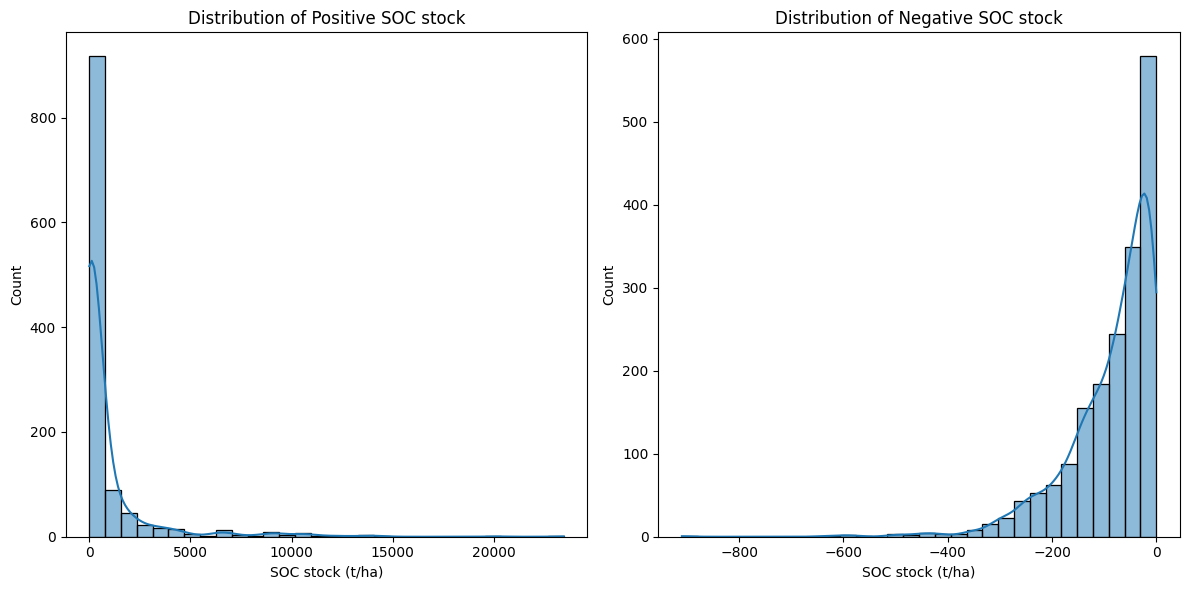

In [87]:
# plot distribution of soc_tha with appropriate scaling
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 6))

# Create two subplots for positive and negative values
plt.subplot(1, 2, 1)
sns.histplot(data=final_dataset[final_dataset['soc_tha'] >= 0], x='soc_tha', bins=30, kde=True)
plt.title("Distribution of Positive SOC stock")
plt.xlabel("SOC stock (t/ha)")

plt.subplot(1, 2, 2)
sns.histplot(data=final_dataset[final_dataset['soc_tha'] < 0], x='soc_tha', bins=30, kde=True)
plt.title("Distribution of Negative SOC stock")
plt.xlabel("SOC stock (t/ha)")

plt.tight_layout()
plt.show()



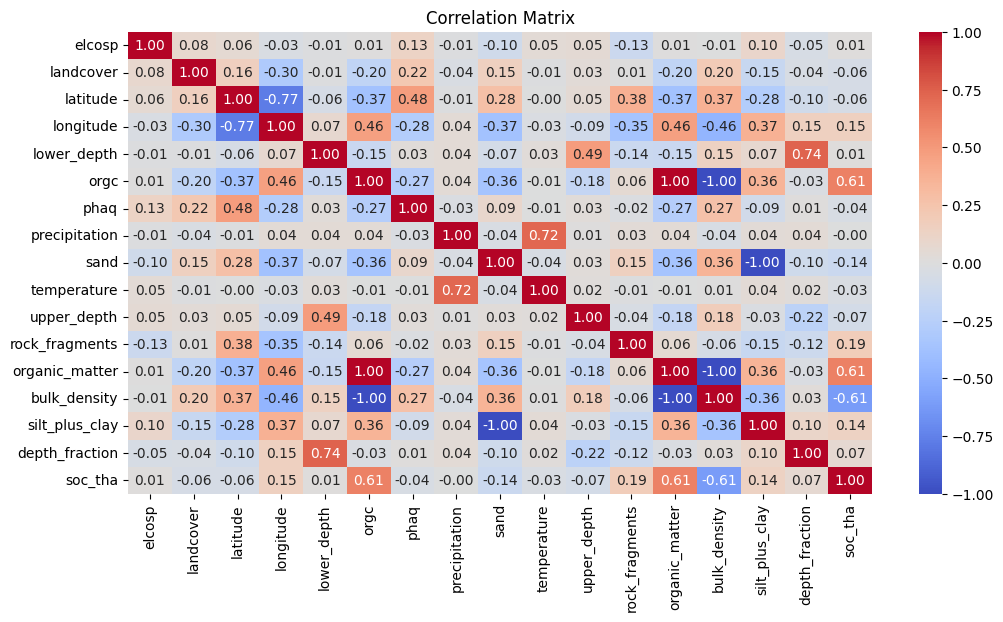

In [88]:
# plot correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

numeric_dataset = final_dataset.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr = numeric_dataset.corr()

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [89]:
# %pip install ccrs cfeature

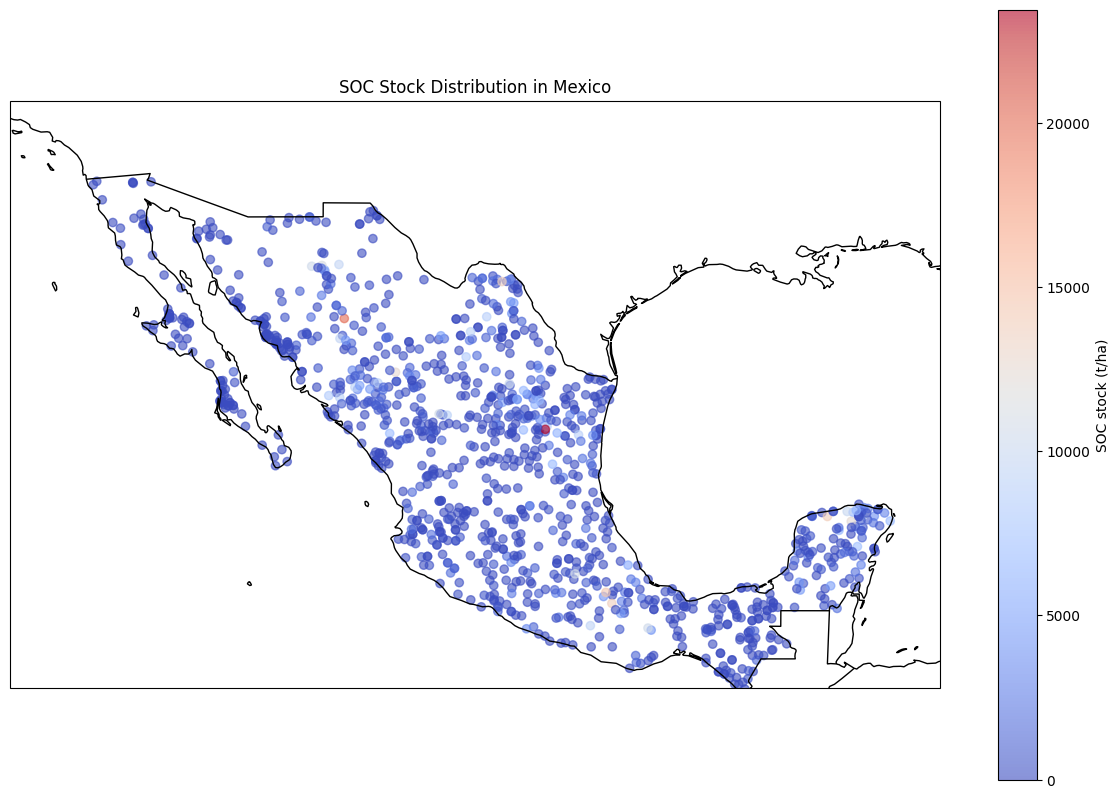

In [90]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Create filtered_data by removing invalid SOC values
filtered_data = final_dataset[
    (final_dataset['soc_tha'].notna()) &  # Remove NaN values
    (final_dataset['soc_tha'] >= 0) # Remove negative values
]

# Create figure and axes with Mercator projection
plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Mercator())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Set the extent of the map to cover Mexico
ax.set_extent([-120, -85, 15, 35], crs=ccrs.PlateCarree())

# Create scatter plot of SOC stock
scatter = ax.scatter(filtered_data['longitude'], 
                    filtered_data['latitude'],
                    c=filtered_data['soc_tha'],
                    cmap='coolwarm',
                    transform=ccrs.PlateCarree(),
                    alpha=0.6)

# Add colorbar
plt.colorbar(scatter, label='SOC stock (t/ha)')

# Add title
plt.title('SOC Stock Distribution in Mexico')

plt.show()

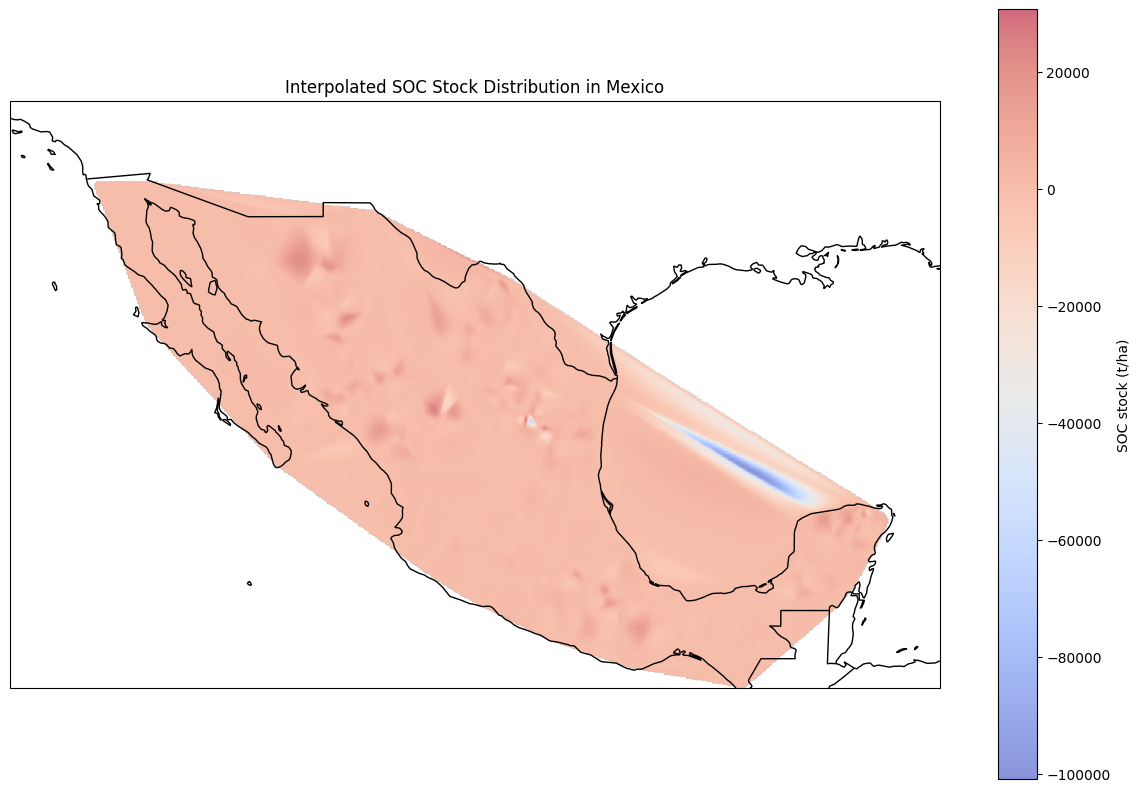

In [91]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.interpolate import griddata

# Create filtered_data by removing invalid SOC values
filtered_data = final_dataset[
    (final_dataset['soc_tha'].notna()) &  # Remove NaN values
    (final_dataset['soc_tha'] >= 0) # Remove negative values
]

# Extract latitude, longitude, and SOC stock values
latitudes = filtered_data['latitude'].values
longitudes = filtered_data['longitude'].values
soc_values = filtered_data['soc_tha'].values

# Define grid for interpolation
grid_lon, grid_lat = np.meshgrid(
    np.linspace(longitudes.min(), longitudes.max(), 500),
    np.linspace(latitudes.min(), latitudes.max(), 500)
)

# Interpolate SOC values on the grid
grid_soc = griddata(
    (longitudes, latitudes), soc_values,
    (grid_lon, grid_lat), method='cubic'
)

# Create figure and axes with Mercator projection
plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Mercator())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Set the extent of the map to cover Mexico
ax.set_extent([-120, -85, 15, 35], crs=ccrs.PlateCarree())

# Plot the interpolated SOC values as a heatmap
heatmap = ax.imshow(grid_soc, extent=[longitudes.min(), longitudes.max(), latitudes.min(), latitudes.max()],
                    origin='lower', cmap='coolwarm', transform=ccrs.PlateCarree(), alpha=0.6)

# Add colorbar
plt.colorbar(heatmap, label='SOC stock (t/ha)')

# Add title
plt.title('Interpolated SOC Stock Distribution in Mexico')

plt.show()

In [92]:
# rename zone_number to ecoregion
final_dataset = final_dataset.rename(columns={'zone_number': 'ecoregion'})

# display dataset
final_dataset.head()

,date,elcosp,landcover,latitude,longitude,lower_depth,orgc,phaq,precipitation,sand,temperature,upper_depth,ecoregion,rock_fragments,organic_matter,bulk_density,silt_plus_clay,depth_fraction,soc_tha
0,10/10/2003,0.2,9.0,28.508804,-106.698715,8,2.0,9.1,113.945740,100.0,15.176553,0,5,13.175046,3.448,1.41312,0.0,8,-27.527682
1,4/13/2005,0.1,17.0,27.462610,-114.098600,20,1.0,8.4,83.411194,86.0,16.085426,0,5,4.552547,1.724,1.51656,14.0,20,-10.775302
2,4/15/2005,0.2,17.0,27.798883,-114.151680,6,2.0,8.4,83.411194,82.0,16.085426,0,5,1.959367,3.448,1.41312,18.0,6,-1.626841
3,5/29/2004,0.0,2.0,17.367722,-93.185150,14,1.0,5.5,147.141876,98.0,16.675776,0,1,1.040600,1.724,1.51656,2.0,14,-0.086202
4,8/6/2003,0.1,7.0,30.903263,-111.515000,18,1.0,7.8,155.092468,88.0,16.817062,0,5,27.627751,1.724,1.51656,12.0,18,-72.688647


In [93]:
drop_columns = ['latitude', 'longitude', 'date', 'orgc', 'bulk_density', 'organic_matter', 'depth_fraction', 'rock_fragments']
target = 'soc_tha'
categorical_columns = ['landcover', 'ecoregion']

# drop columns
df = final_dataset.drop(columns=drop_columns)
print("Columns in the dataset: \n", df.columns)

# replace roman numbers in ecoregion column
df['ecoregion'] = df['ecoregion'].str.replace('VII', '7').str.replace('VI', '6')
print("Unique values in ecoregion: ", df['ecoregion'].unique())

# convert landcover values from decimal to integer
df['landcover'] = df['landcover'].astype(int)

# one-hot encode categorical columns
df = pd.get_dummies(df, columns=categorical_columns, prefix_sep='_', prefix=categorical_columns, drop_first=True)
print("Columns in the dataset after one-hot encoding: \n", df.columns)

print("Shape of the dataset: ", df.shape)

# drop missing values
df = df.dropna()
print("Shape of the dataset after dropping missing values: ", df.shape)

# drop duplicates
df = df.drop_duplicates()
print("Shape of the dataset after dropping duplicates: ", df.shape)

# save the dataset
df_path = "D:/tierra/datasets/mexico_soc_dataset_encoded.csv"
df.to_csv(df_path, index=False)

# disable column width restriction
pd.set_option('display.max_columns', None)
df.head()

Columns in the dataset: 
 Index(['elcosp', 'landcover', 'lower_depth', 'phaq', 'precipitation', 'sand',
       'temperature', 'upper_depth', 'ecoregion', 'silt_plus_clay', 'soc_tha'],
      dtype='object')
Unique values in ecoregion:  ['5' '1' '4' '2' '7' '6' '3']
Columns in the dataset after one-hot encoding: 
 Index(['elcosp', 'lower_depth', 'phaq', 'precipitation', 'sand', 'temperature',
       'upper_depth', 'silt_plus_clay', 'soc_tha', 'landcover_2',
       'landcover_4', 'landcover_5', 'landcover_6', 'landcover_7',
       'landcover_8', 'landcover_9', 'landcover_10', 'landcover_11',
       'landcover_12', 'landcover_13', 'landcover_14', 'landcover_16',
       'landcover_17', 'ecoregion_2', 'ecoregion_3', 'ecoregion_4',
       'ecoregion_5', 'ecoregion_6', 'ecoregion_7'],
      dtype='object')
Shape of the dataset:  (3003, 29)
Shape of the dataset after dropping missing values:  (2984, 29)
Shape of the dataset after dropping duplicates:  (2984, 29)


,elcosp,lower_depth,phaq,precipitation,sand,temperature,upper_depth,silt_plus_clay,soc_tha,landcover_2,landcover_4,landcover_5,landcover_6,landcover_7,landcover_8,landcover_9,landcover_10,landcover_11,landcover_12,landcover_13,landcover_14,landcover_16,landcover_17,ecoregion_2,ecoregion_3,ecoregion_4,ecoregion_5,ecoregion_6,ecoregion_7
0,0.2,8,9.1,113.945740,100.0,15.176553,0,0.0,-27.527682,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,0.1,20,8.4,83.411194,86.0,16.085426,0,14.0,-10.775302,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
2,0.2,6,8.4,83.411194,82.0,16.085426,0,18.0,-1.626841,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
3,0.0,14,5.5,147.141876,98.0,16.675776,0,2.0,-0.086202,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.1,18,7.8,155.092468,88.0,16.817062,0,12.0,-72.688647,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


Training set shape: (2387, 28) (2387,)
Testing set shape: (597, 28) (597,)
Model: Random Forest
MSE: 1807806.598786971 MAE: 515.460632786268 RMSE: 1344.5469864556505 R2: 0.011629638223521033
------------------------------
Feature Importances: 
 ['lower_depth', 'phaq', 'temperature', 'elcosp', 'sand', 'precipitation', 'silt_plus_clay', 'landcover_10', 'landcover_7', 'ecoregion_4', 'landcover_14', 'landcover_2', 'upper_depth', 'landcover_9', 'ecoregion_5', 'ecoregion_2', 'ecoregion_3', 'landcover_8', 'landcover_12', 'landcover_16', 'landcover_17', 'landcover_4', 'landcover_11', 'ecoregion_7', 'landcover_5', 'landcover_13', 'landcover_6', 'ecoregion_6']


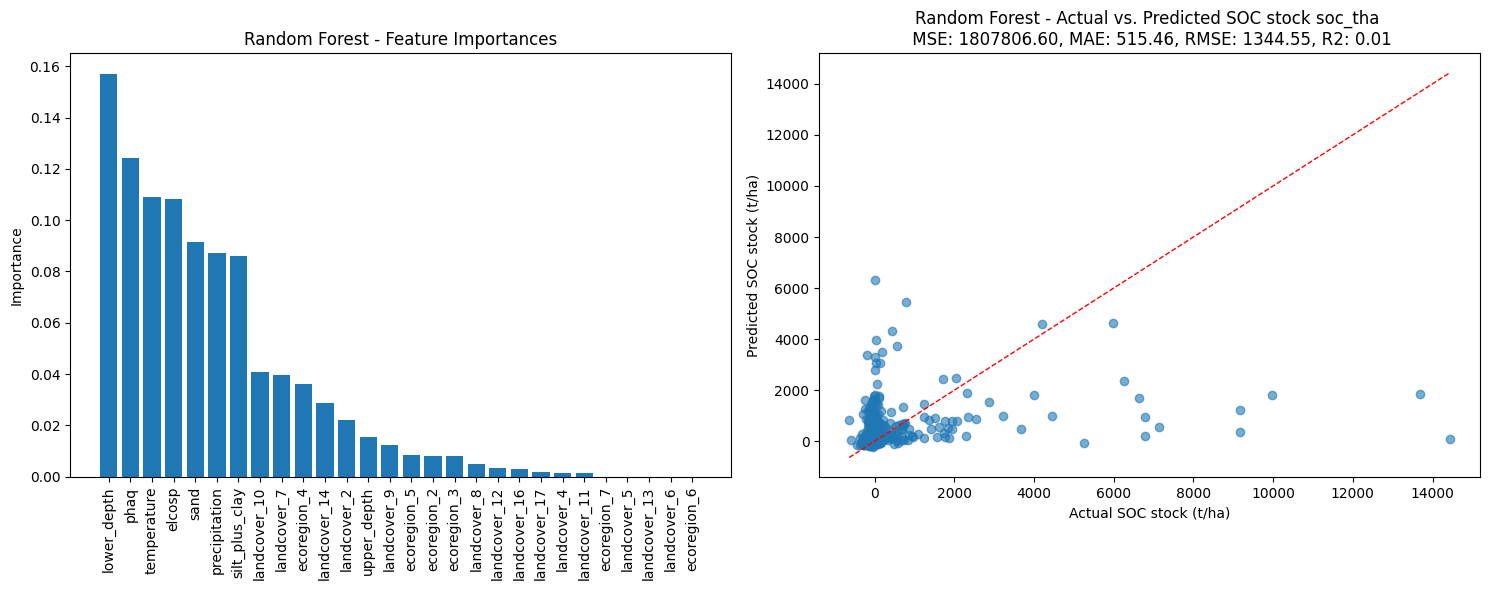

Model: Gradient Boosting
MSE: 1618906.0120135995 MAE: 501.1436855163167 RMSE: 1272.362374488337 R2: 0.1149060293011196
------------------------------
Feature Importances: 
 ['elcosp', 'temperature', 'landcover_14', 'phaq', 'lower_depth', 'precipitation', 'ecoregion_4', 'landcover_10', 'landcover_7', 'silt_plus_clay', 'landcover_2', 'sand', 'landcover_9', 'ecoregion_3', 'landcover_16', 'ecoregion_2', 'upper_depth', 'landcover_11', 'ecoregion_5', 'landcover_8', 'landcover_5', 'landcover_12', 'ecoregion_6', 'ecoregion_7', 'landcover_13', 'landcover_17', 'landcover_4', 'landcover_6']


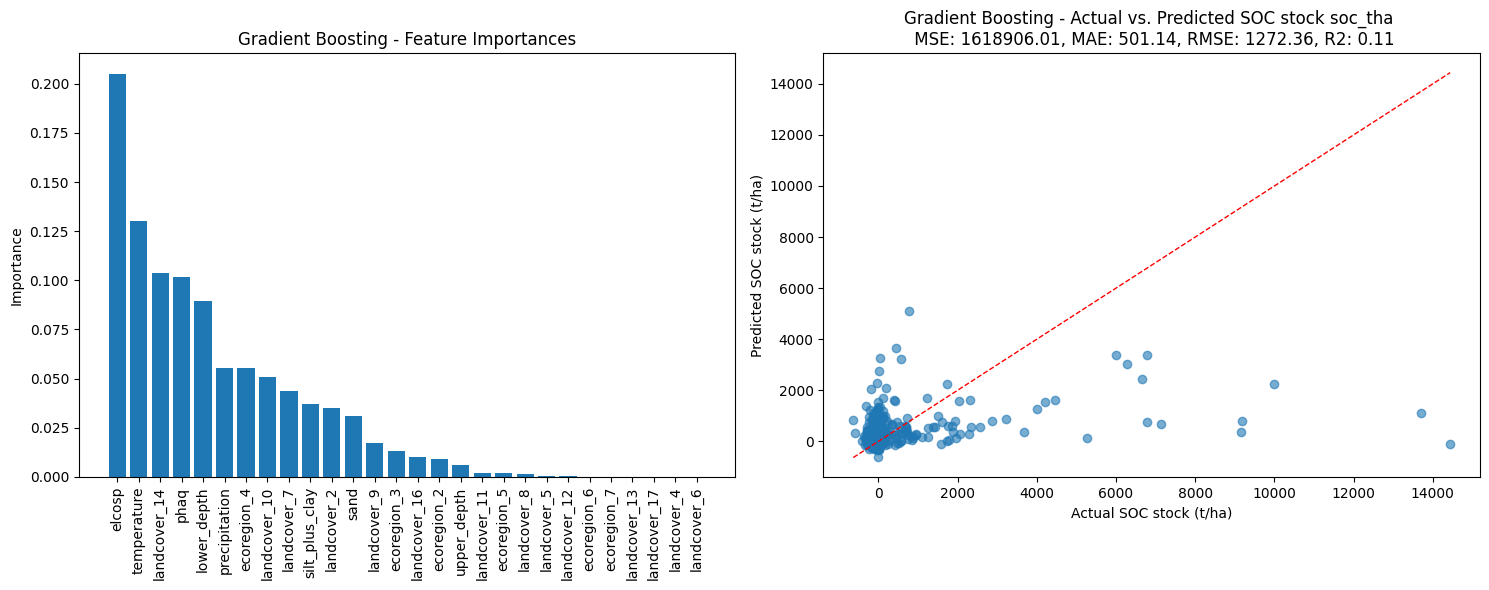

In [94]:
# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Split the data into features and target
X = df.drop(columns=[target])
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

# Initialize the models
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate the mean squared error
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {name}")
    print("MSE:", mse, "MAE:", mae, "RMSE:", rmse, "R2:", r2)
    print("-"*30)

    # Get feature importances if the model supports it
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    if hasattr(model, 'feature_importances_'):
        # Get importance values
        importances = model.feature_importances_
        
        # Sort feature importances in descending order
        indices = np.argsort(importances)[::-1]
        
        # Rearrange feature names so they match the sorted feature importances
        feature_names = X.columns[indices]
        print("Feature Importances: \n", feature_names.tolist())
        
        # Plot feature importances as a bar chart
        ax1.bar(range(X_train_scaled.shape[1]), importances[indices])
        ax1.set_xticks(range(X_train_scaled.shape[1]))
        ax1.set_xticklabels(feature_names, rotation=90)
        ax1.set_title(f"{name} - Feature Importances")
        ax1.set_ylabel("Importance")
        

    # Plot the actual values
    ax2.scatter(y_test, y_pred, alpha=0.6)

    # Add a line for perfect correlation
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)

    # Add labels and title
    ax2.set_xlabel("Actual SOC stock (t/ha)")
    ax2.set_ylabel("Predicted SOC stock (t/ha)")
    ax2.set_title(f"{name} - Actual vs. Predicted SOC stock {target} \n MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

    plt.tight_layout()
    plt.show()